# MaPLe (Simplified): Multi-Modal Prompt Learning for CLIP

This notebook implements a **shallow, single-layer simplification** of MaPLe (Khattak et al., CVPR 2023), reviewed in Section 2.2.3 of the report.

**What the real MaPLe does:** learns context prompts in the text branch and couples them into the vision branch via a projection function, injected at **9 of 12 transformer layers** (deep prompting across the feature hierarchy).

**What this notebook does (the simplification, stated explicitly for the report):**
- Learnable text context vectors `ctx` (CoOp-style), inserted into the text prompt embedding **once, at the input layer only**.
- A single linear **coupling function** projects `ctx` into a small number of visual prompt tokens, prepended to the patch-token sequence **once, at the input layer of the ViT only** — not at every layer.
- Both CLIP encoders remain otherwise entirely frozen; only `ctx` and the coupling linear layer are trained.

This captures MaPLe's core idea — text-conditioned vision prompts — without the full 9-layer deep-prompting architecture, which is out of scope for this timeframe. Same simplification-for-transparency spirit as the char-level tokenizer used in Section 5.3 of the report.

---

In [1]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
print("\u2705 Installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Installed.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
import numpy as np
import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset

import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")

Running on: CUDA


## 1 — Load CLIP and CIFAR-10

In [3]:
print("Loading CLIP model (ViT-B/32)...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model = clip_model.float()
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False

D_TEXT = clip_model.token_embedding.embedding_dim
D_VISION = clip_model.visual.conv1.out_channels
print(f"\u2705 CLIP loaded! d_text={D_TEXT}, d_vision={D_VISION}")

Loading CLIP model (ViT-B/32)...


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 79.9MiB/s]


✅ CLIP loaded! d_text=512, d_vision=768


In [4]:
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
raw_cifar10 = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

indices_per_class = {c: [] for c in range(10)}
for idx, (_, label) in enumerate(raw_cifar10):
    if len(indices_per_class[label]) < 50:
        indices_per_class[label].append(idx)
    if all(len(v) == 50 for v in indices_per_class.values()):
        break
test_indices = [idx for idxs in indices_per_class.values() for idx in idxs]
print(f"Test set: {len(test_indices)} images (50 per class)")

def build_shot_subset(k):
    indices = []
    seen = {c: 0 for c in range(10)}
    for idx, (_, label) in enumerate(cifar_train):
        if seen[label] < k:
            indices.append(idx)
            seen[label] += 1
        if all(v == k for v in seen.values()):
            break
    return indices

def preprocess_batch(dataset, indices):
    imgs = torch.stack([clip_preprocess(transforms.ToPILImage()(dataset[i][0])) for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])
    return imgs.to(DEVICE), labels.to(DEVICE)

100%|██████████| 170M/170M [00:41<00:00, 4.14MB/s]


Test set: 500 images (50 per class)


---

## 2 — Multi-modal prompt module: learnable text context + vision coupling

In [5]:
N_CTX = 4  # number of learnable context tokens

class MaPLePrompts(nn.Module):
    def __init__(self, classnames, n_ctx=N_CTX, d_text=D_TEXT, d_vision=D_VISION):
        super().__init__()
        self.n_ctx = n_ctx
        self.n_cls = len(classnames)

        # Learnable text context vectors (shared across classes, CoOp-style)
        self.ctx = nn.Parameter(torch.randn(n_ctx, d_text) * 0.02)

        # Coupling function: projects text context -> vision prompt tokens
        self.coupling_fn = nn.Linear(d_text, d_vision)

        # Precompute the fixed (non-learnable) parts of each class's tokenized prompt:
        # template "X X X X {classname}." -- the 'X' placeholder positions are
        # overwritten with self.ctx at every forward pass.
        prompt_prefix = " ".join(["X"] * n_ctx)
        prompts = [f"{prompt_prefix} {name}." for name in classnames]
        tokenized = clip.tokenize(prompts).to(DEVICE)
        self.register_buffer("tokenized_prompts", tokenized)

        with torch.no_grad():
            embedding = clip_model.token_embedding(tokenized).type(clip_model.dtype)
        self.register_buffer("token_prefix", embedding[:, :1, :])                 # SOS token
        self.register_buffer("token_suffix", embedding[:, 1 + n_ctx:, :])          # classname + EOS + padding

    def build_text_embeddings(self):
        ctx_expanded = self.ctx.unsqueeze(0).expand(self.n_cls, -1, -1)
        return torch.cat([self.token_prefix, ctx_expanded, self.token_suffix], dim=1)

    def build_vision_prompts(self):
        return self.coupling_fn(self.ctx)   # [n_ctx, d_vision]

prompt_module = MaPLePrompts(CIFAR10_CLASSES).to(DEVICE)
print(f"Trainable parameters: ctx={prompt_module.ctx.numel()}, "
      f"coupling_fn={sum(p.numel() for p in prompt_module.coupling_fn.parameters())}")

Trainable parameters: ctx=2048, coupling_fn=393984


## 3 — Custom forward passes with prompt injection

In [6]:
def encode_text_with_prompts(prompt_module):
    """Re-implements CLIP.encode_text, but with learnable context spliced in."""
    x = prompt_module.build_text_embeddings()               # [n_cls, 77, d_text]
    x = x + clip_model.positional_embedding.type(clip_model.dtype)
    x = x.permute(1, 0, 2)                                    # NLD -> LND
    x = clip_model.transformer(x)
    x = x.permute(1, 0, 2)                                    # LND -> NLD
    x = clip_model.ln_final(x).type(clip_model.dtype)
    eot_idx = prompt_module.tokenized_prompts.argmax(dim=-1)
    x = x[torch.arange(x.shape[0]), eot_idx] @ clip_model.text_projection
    return x

def encode_image_with_prompts(images, prompt_module):
    """Re-implements CLIP.visual forward, prepending vision prompt tokens
    (derived from the text context via the coupling function) after the CLS token."""
    visual = clip_model.visual
    x = visual.conv1(images.type(clip_model.dtype))            # [B, width, grid, grid]
    x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)  # [B, grid**2, width]

    cls_tok = visual.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], device=x.device, dtype=x.dtype)
    x = torch.cat([cls_tok, x], dim=1)                          # prepend CLS
    x = x + visual.positional_embedding.to(x.dtype)

    vision_prompts = prompt_module.build_vision_prompts().unsqueeze(0).expand(x.shape[0], -1, -1)
    x = torch.cat([x[:, :1, :], vision_prompts.type(x.dtype), x[:, 1:, :]], dim=1)  # insert after CLS, before patches

    x = visual.ln_pre(x)
    x = x.permute(1, 0, 2)                                      # NLD -> LND
    x = visual.transformer(x)
    x = x.permute(1, 0, 2)                                      # LND -> NLD

    x = visual.ln_post(x[:, 0, :])                              # CLS token output
    if visual.proj is not None:
        x = x @ visual.proj
    return x

---

## 4 — Train the prompts on the K-shot support set

In [7]:
def train_maple(k, epochs=25, lr=2e-3, batch_size=32):
    prompts = MaPLePrompts(CIFAR10_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(
        list(prompts.parameters()), lr=lr
    )
    criterion = nn.CrossEntropyLoss()

    train_idx = build_shot_subset(k)
    train_imgs, train_labels = preprocess_batch(cifar_train, train_idx)
    n_samples = train_imgs.shape[0]

    for epoch in range(epochs):
        perm = torch.randperm(n_samples)
        for start in range(0, n_samples, batch_size):
            batch_idx = perm[start:start + batch_size]
            bx, by = train_imgs[batch_idx], train_labels[batch_idx]

            img_feats = encode_image_with_prompts(bx, prompts)
            img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
            txt_feats = encode_text_with_prompts(prompts)
            txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)

            logits = 100.0 * img_feats @ txt_feats.T
            loss = criterion(logits, by)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    n_trainable = sum(p.numel() for p in prompts.parameters())
    return prompts, n_trainable

def eval_maple(prompts, test_imgs, test_labels):
    with torch.no_grad():
        img_feats = encode_image_with_prompts(test_imgs, prompts)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
        txt_feats = encode_text_with_prompts(prompts)
        txt_feats = txt_feats / txt_feats.norm(dim=-1, keepdim=True)
        logits = 100.0 * img_feats @ txt_feats.T
        preds = logits.argmax(dim=1)
    return (preds == test_labels).float().mean().item() * 100

In [8]:
# ── Zero-shot baseline for comparison ────────────────────────────────────────
text_prompts_zs = [f"a photo of a {c}" for c in CIFAR10_CLASSES]
text_tokens_zs = clip.tokenize(text_prompts_zs).to(DEVICE)
test_imgs, test_labels = preprocess_batch(raw_cifar10, test_indices)

with torch.no_grad():
    zs_text = clip_model.encode_text(text_tokens_zs)
    zs_text = zs_text / zs_text.norm(dim=-1, keepdim=True)
    zs_img = clip_model.encode_image(test_imgs)
    zs_img = zs_img / zs_img.norm(dim=-1, keepdim=True)
    zs_logits = 100.0 * zs_img @ zs_text.T
    zeroshot_acc = (zs_logits.argmax(dim=1) == test_labels).float().mean().item() * 100

print(f"Zero-shot CLIP accuracy on this test set: {zeroshot_acc:.1f}%")

Zero-shot CLIP accuracy on this test set: 90.4%


In [9]:
# ── Run the K-shot sweep ─────────────────────────────────────────────────────
K_VALUES = [1, 5, 10, 50, 100]
results = {'accuracy': {}, 'n_trainable': {}}

print(f"{'K':>5} {'Zero-shot':>10} {'MaPLe (simplified)':>20}")
print("-" * 38)

for k in K_VALUES:
    epochs = 25 if k <= 20 else 12
    prompts, n_trainable = train_maple(k, epochs=epochs)
    acc = eval_maple(prompts, test_imgs, test_labels)

    results['accuracy'][k] = acc
    results['n_trainable'][k] = n_trainable

    print(f"{k:>5} {zeroshot_acc:>9.1f}% {acc:>19.1f}%")

print("-" * 38)
print(f"\nTrainable parameters (ctx + coupling_fn): {results['n_trainable'][K_VALUES[0]]:,}")

    K  Zero-shot   MaPLe (simplified)
--------------------------------------
    1      90.4%                90.2%
    5      90.4%                91.2%
   10      90.4%                90.4%
   50      90.4%                94.6%
  100      90.4%                94.6%
--------------------------------------

Trainable parameters (ctx + coupling_fn): 396,032


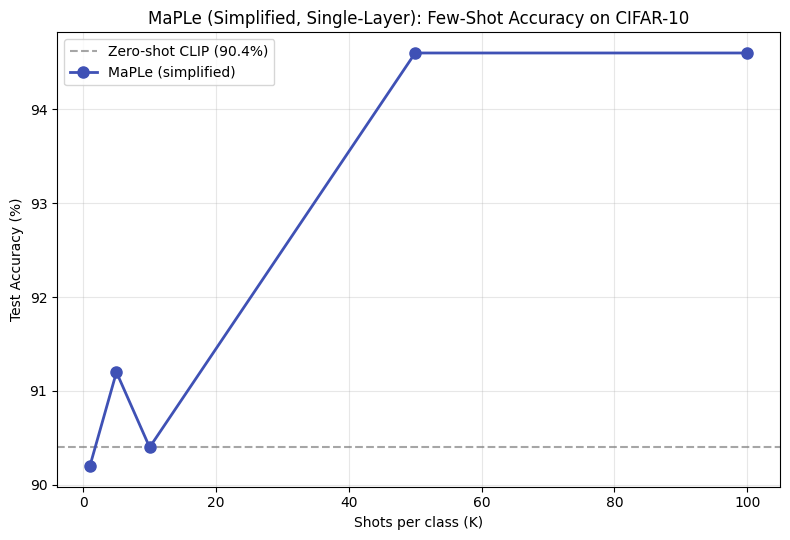

In [10]:
# ── Plot the few-shot learning curve ─────────────────────────────────────────
plt.figure(figsize=(8, 5.5))
plt.axhline(zeroshot_acc, color='gray', linestyle='--', alpha=0.7, label=f'Zero-shot CLIP ({zeroshot_acc:.1f}%)')
plt.plot(K_VALUES, [results['accuracy'][k] for k in K_VALUES], 'o-', linewidth=2, markersize=8, color='#3F51B5', label='MaPLe (simplified)')
plt.xlabel('Shots per class (K)')
plt.ylabel('Test Accuracy (%)')
plt.title('MaPLe (Simplified, Single-Layer): Few-Shot Accuracy on CIFAR-10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('maple_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Note on fidelity (important for the report/defense)

State this explicitly in Chapter 5/6: this is a **single-layer, single-coupling-point reproduction** of MaPLe's core mechanism, not the full 9-layer deep multi-modal prompting from Khattak et al. Accuracy numbers here should **not** be directly compared to the paper's reported 78.55% Harmonic Mean — that number comes from the full architecture on different (larger, higher-resolution) benchmarks. Use this notebook to demonstrate the *mechanism* (text-conditioned vision prompts, gradient flow, few-shot improvement over zero-shot) rather than to claim paper-matching performance.